In [14]:
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.manifold import TSNE
import time
import psutil
import os
from functools import wraps
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

In [2]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "akhiljethwa/world-energy-statistics"
)

print("Dataset path:", path)

df = pd.read_csv(path + "/World Energy Overview.csv")

print(df.head())
print(df.info())
print(df.describe())
duplicates_count = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates_count}")

100%|██████████| 354k/354k [00:00<00:00, 772kB/s]

Extracting files...
Dataset path: data/kagglehub_cache\datasets\akhiljethwa\world-energy-statistics\versions\2
         Date  Total Fossil Fuels Production  \
0  1973-01-31                       4.932632   
1  1973-02-28                       4.729582   
2  1973-03-31                       4.946902   
3  1973-04-30                       4.716271   
4  1973-05-31                       4.956995   

   Nuclear Electric Power Production  Total Renewable Energy Production  \
0                           0.068103                           0.403981   
1                           0.064634                           0.360900   
2                           0.072494                           0.400161   
3                           0.064070                           0.380470   
4                           0.062111                           0.392141   

   Total Primary Energy Production  Primary Energy Imports  \
0                         5.404715                1.173080   
1                        

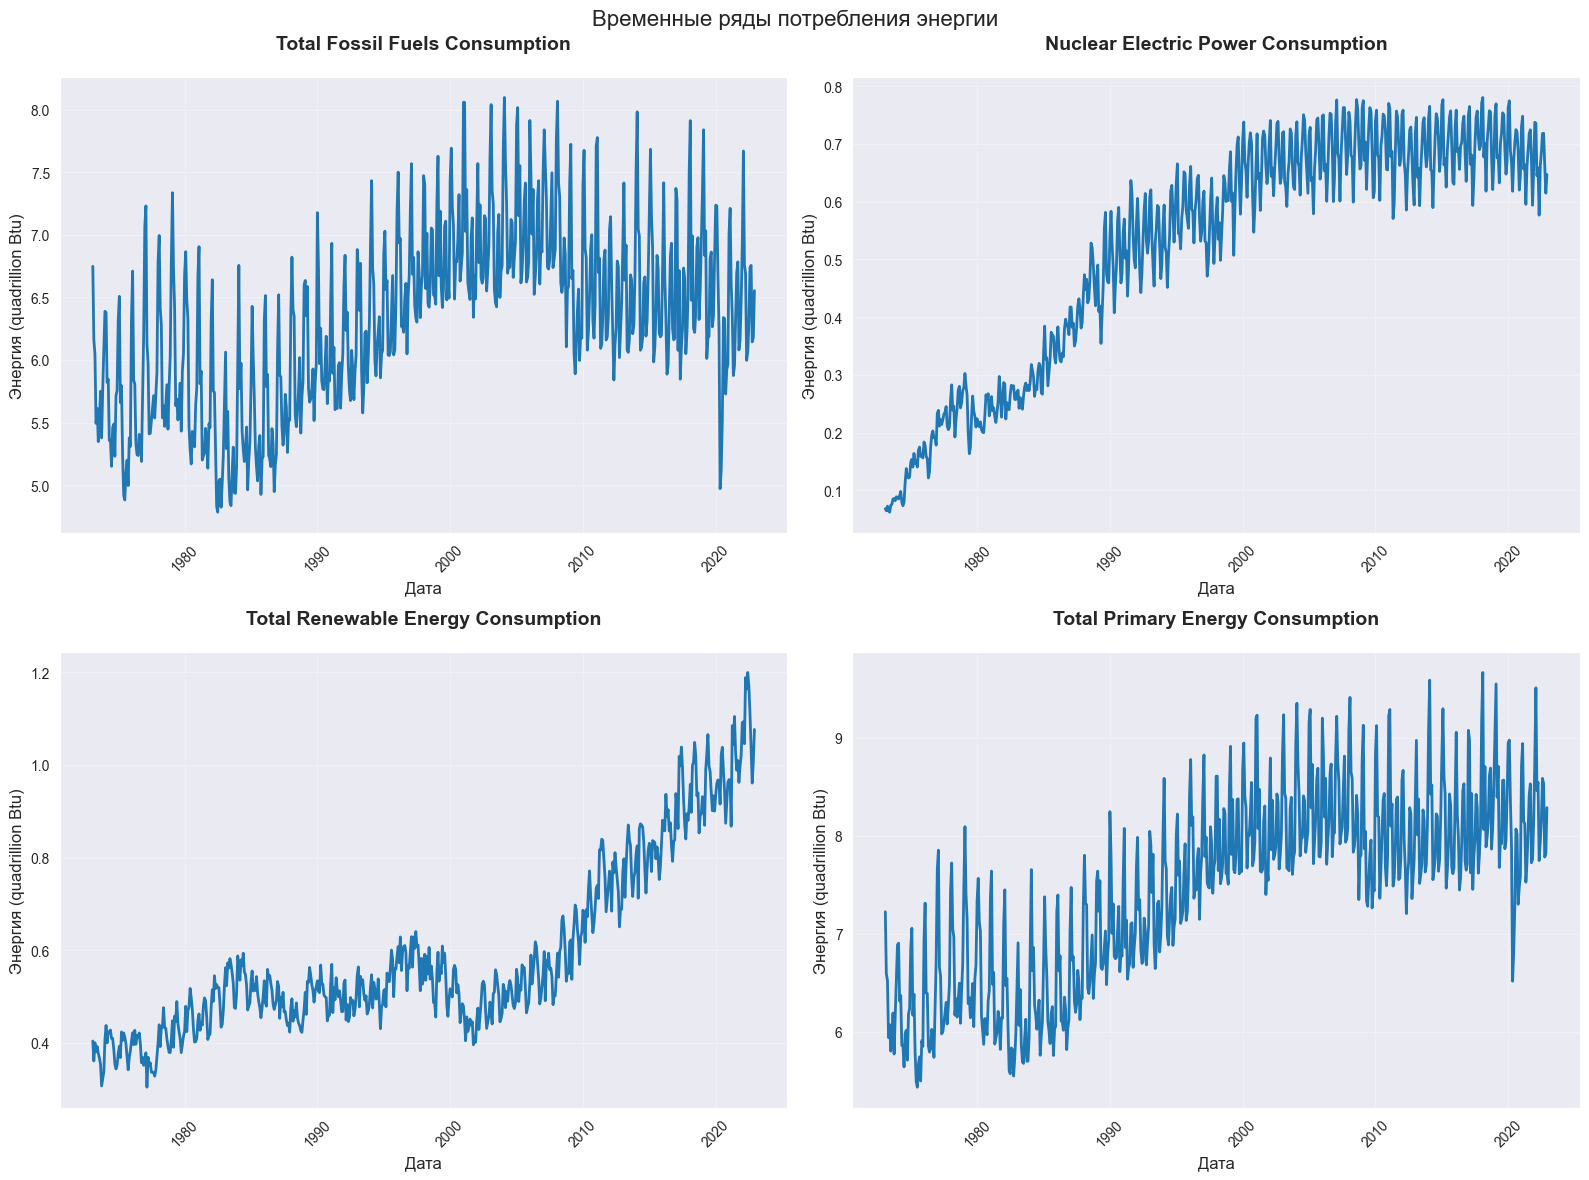

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

consumption_cols = [col for col in df.columns if 'Consumption' in col]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(consumption_cols):
    axes[i].plot(df.index, df[col], linewidth=2)
    axes[i].set_title(col, fontsize=14, fontweight='bold', pad=20)
    axes[i].set_xlabel('Дата', fontsize=12)
    axes[i].set_ylabel('Энергия (quadrillion Btu)', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Временные ряды потребления энергии', fontsize=16)
plt.tight_layout()
plt.show()

# Fossil Fuels

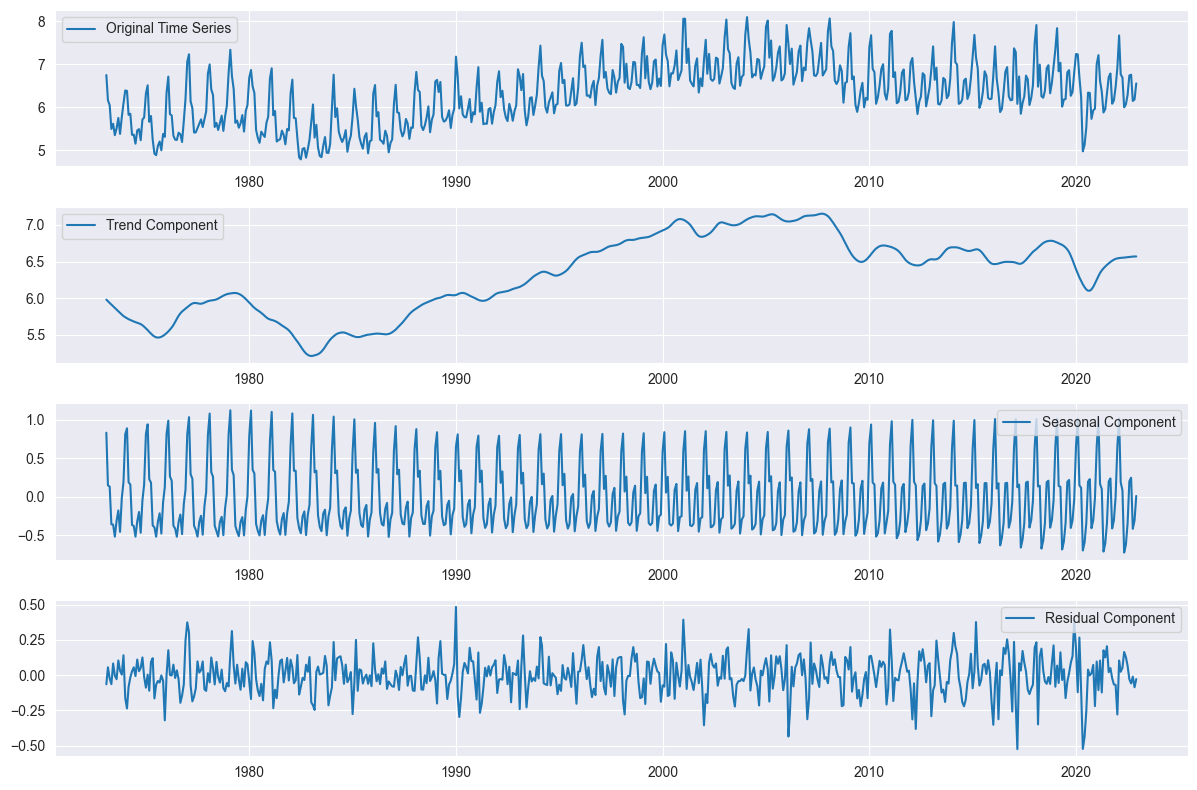

In [9]:
stl_fossil = STL(df['Total Fossil Fuels Consumption'], seasonal=13)
result_fossil = stl_fossil.fit()
# Извлечение компонентов
trend = result_fossil.trend
seasonal = result_fossil.seasonal
residual = result_fossil.resid

# Построение графика декомпозиции
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df['Total Fossil Fuels Consumption'], label='Original Time Series')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend Component')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal Component')
plt.legend(loc='upper right')
plt.subplot(414)
plt.plot(residual, label='Residual Component')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

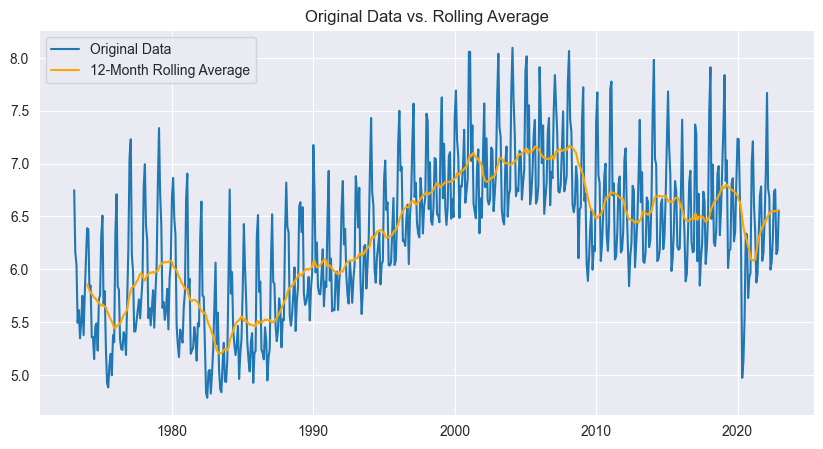

In [13]:
# Расчет скользящего среднего за 12 месяцев
df['rolling_avg'] = df['Total Fossil Fuels Consumption'].rolling(window=12).mean()

plt.figure(figsize=(10, 5))
plt.plot(df['Total Fossil Fuels Consumption'], label='Original Data')
plt.plot(df['rolling_avg'], label='12-Month Rolling Average', color='orange')
plt.title('Original Data vs. Rolling Average')
plt.legend()
plt.show()

In [15]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    return result[1]

for column in df.columns:
    p_value = check_stationarity(df[column])
    print(f"Column '{column}': p‑value = {p_value}")
    if p_value <= 0.05:
        print(f"The series '{column}' is likely stationary")
    else:
        print(f"The series '{column}' is likely non‑stationary")
        print()

Column 'Total Fossil Fuels Production': p‑value = 0.9880654916763072
The series 'Total Fossil Fuels Production' is likely non‑stationary

Column 'Nuclear Electric Power Production': p‑value = 0.01192218672167184
The series 'Nuclear Electric Power Production' is likely stationary
Column 'Total Renewable Energy Production': p‑value = 0.9972946112835634
The series 'Total Renewable Energy Production' is likely non‑stationary

Column 'Total Primary Energy Production': p‑value = 0.9935345678747358
The series 'Total Primary Energy Production' is likely non‑stationary

Column 'Primary Energy Imports': p‑value = 0.505322565922393
The series 'Primary Energy Imports' is likely non‑stationary

Column 'Primary Energy Exports': p‑value = 1.0
The series 'Primary Energy Exports' is likely non‑stationary

Column 'Primary Energy Net Imports': p‑value = 0.9395197550989337
The series 'Primary Energy Net Imports' is likely non‑stationary

Column 'Primary Energy Stock Change and Other': p‑value = 6.97642527

MissingDataError: exog contains inf or nans